# Sentiment Analysis
This notebook serves as the starting point for a project aimed at comparing the effectiveness of selected Natural Language Processing models in sentiment analysis.

**Project Scope**

Sentiment analysis is an NLP task that involves identifying and classifying emotions or opinions expressed in text. In this study, I aim to evaluate the performance of the following models:

- Support Vector Machines (SVM)
- Convolutional Neural Networks (CNN)
- Long Short-Term Memory Networks (LSTM)
- Bidirectional Encoder Representations from Transformers (BERT)

The analysis will be conducted using datasets - Sentiment140, Amazon Books Reviews and Yelp Reviews.

**Notebook Scope**

In this notebook, the data is prepared, analyzed, preprocessed, split, and saved into specific datasets. 

# 1. Data Loading
In this section, the raw datasets are loaded into memory. The process includes importing essential libraries, defining dataset paths, and reading data into Pandas DataFrames. This step ensures the data is accessible and ready for further analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_utils import DataUtils

In [3]:
# load datasets
amazon_file = '../data/raw/amazon_books_ratings.csv'
sentiment140_file = '../data/raw/sentiment140.csv'
yelp_file = '../data/raw/yelp_reviews.csv'

# read datasets
amazon_df = pd.read_csv(amazon_file, engine='python', names=["Polarity", "Review"], skiprows=1, usecols=[6, 8], encoding="ISO-8859-1")
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', names=["Polarity", "Review"], usecols=[0, 5], encoding="ISO-8859-1")
yelp_df = pd.read_csv(yelp_file, engine='python', names=["Polarity", "Review"], encoding="ISO-8859-1")

In [4]:
# inspect dataframes
print("Amazon Books Reviews DataFrame:")
print(amazon_df.head())
print("\nSentiment140 DataFrame:")
print(sentiment140_df.head())
print("\nYelp Reviews DataFrame:")
print(yelp_df.head())

Amazon Books Reviews DataFrame:
   Polarity                                           Review
0       4.0           Nice collection of Julie Strain images
1       5.0                                Really Enjoyed It
2       5.0  Essential for every personal and Public Library
3       4.0  Phlip Nel gives silly Seuss a serious treatment
4       4.0                           Good academic overview

Sentiment140 DataFrame:
   Polarity                                             Review
0         0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1         0  is upset that he can't update his Facebook by ...
2         0  @Kenichan I dived many times for the ball. Man...
3         0    my whole body feels itchy and like its on fire 
4         0  @nationwideclass no, it's not behaving at all....

Yelp Reviews DataFrame:
   Polarity                                             Review
0         1  Unfortunately, the frustration of being Dr. Go...
1         2  Been going to Dr. Goldberg for over

# 2. Exploratory Data Analysis
This section focuses on exploring the loaded datasets to understand their structure and key characteristics. 

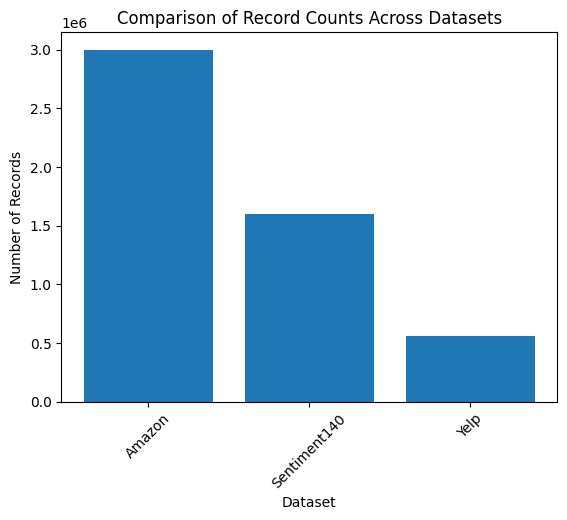

In [5]:
# plot chart showing the number of records per dataset
data = {'Dataset': ['Amazon', 'Sentiment140', 'Yelp'], 'Number of Records': [len(amazon_df), len(sentiment140_df), len(yelp_df)]}

df = pd.DataFrame(data)

plt.bar(df['Dataset'], df['Number of Records'])
plt.xlabel('Dataset') 
plt.ylabel('Number of Records')
plt.title('Comparison of Record Counts Across Datasets')
plt.xticks(rotation=45) 
plt.show()

In [6]:
# list of dataframes and their names
dfs = [amazon_df, sentiment140_df, yelp_df]
dataset_names = ['Amazon', 'Sentiment140', 'Yelp']

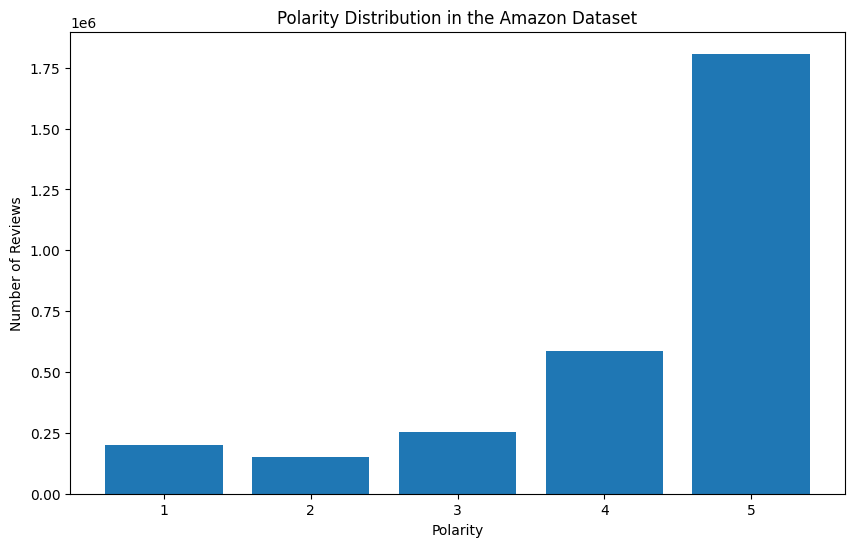

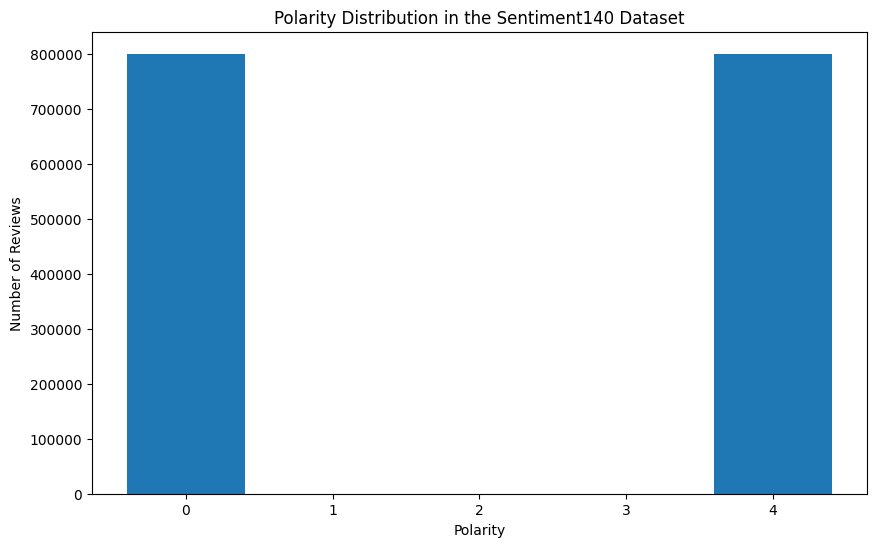

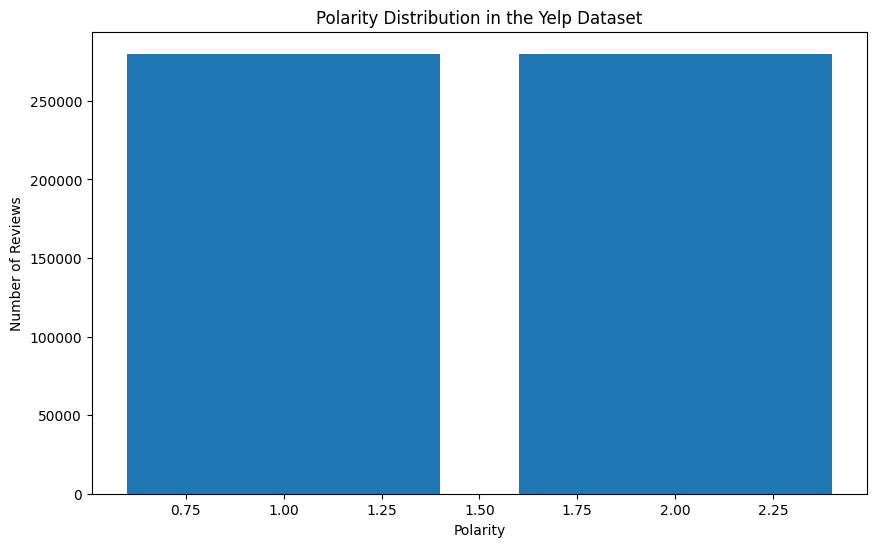

In [7]:
# plot distribution of review polarity across datasets
for df, name in zip(dfs, dataset_names):
    DataUtils.plot_polarity_distribution(df, name)

In [8]:
import nltk

# download the tokenizer for sentence and word tokenization
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Bartek\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

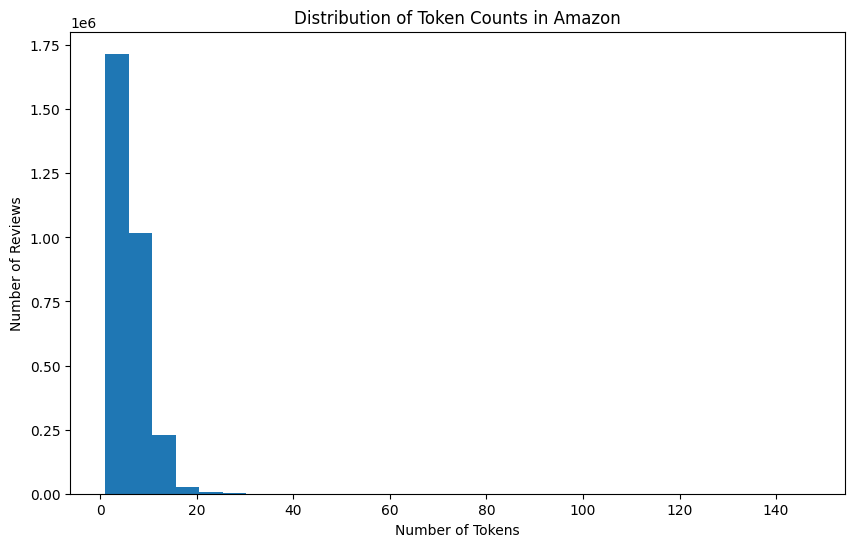

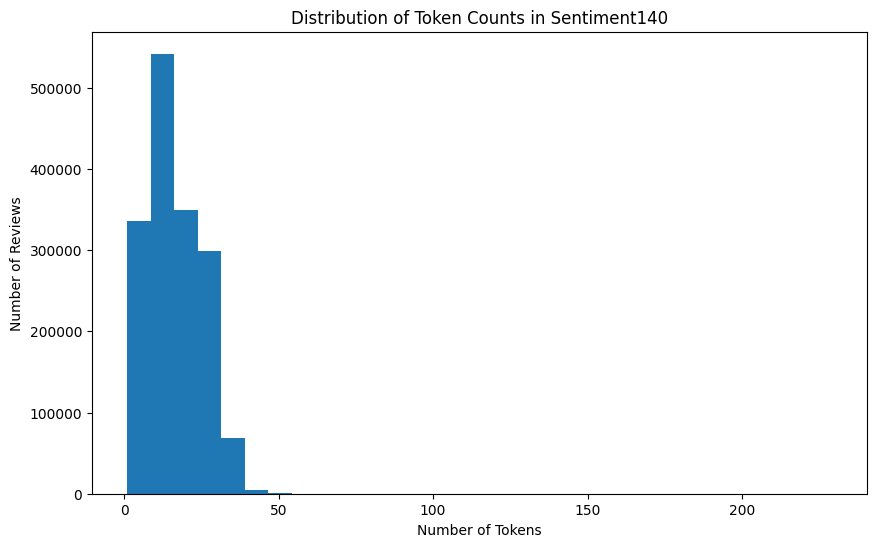

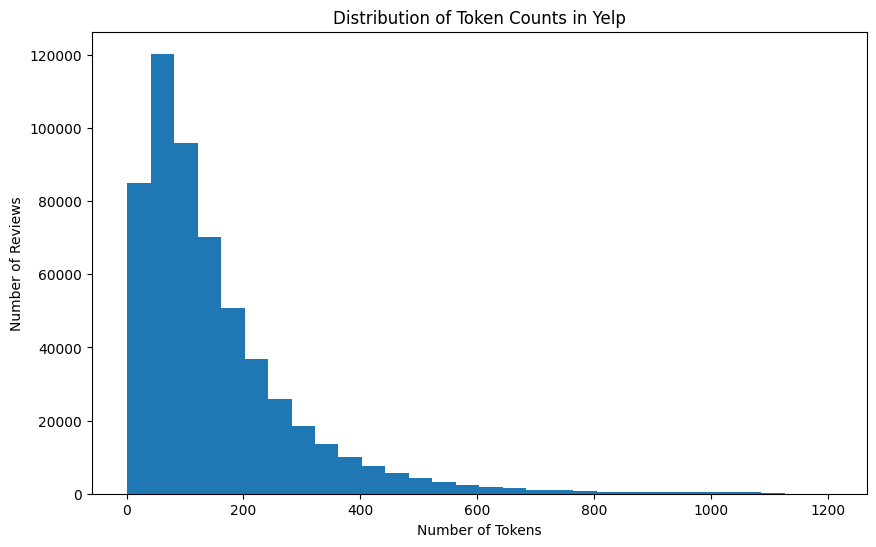

In [9]:
# plot the distribution of token counts across datasets by polarity
for df, name in zip(dfs, dataset_names):
    DataUtils.plot_token_distribution(df, name)

# 3. Data Preprocessing
Here, the datasets are prepared for analysis by applying a series of preprocessing steps. These include:

- Cleaning the data by removing null values and irrelevant records.
- Tokenizing text into smaller components, such as words or sentences.
- Lemmatizing words to reduce them to their base or root form.

In [10]:
# download the stopwords dict and lemmatizer for data processing
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bartek\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Bartek\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 3.1 Data Preprocessing - Amazon Books Ratings

In [11]:
# standardize the dataset
# count the number of records for each class
count_1 = len(amazon_df[amazon_df['Polarity'] == 1.0])
count_2 = len(amazon_df[amazon_df['Polarity'] == 2.0])
count_4 = len(amazon_df[amazon_df['Polarity'] == 4.0])
count_5 = len(amazon_df[amazon_df['Polarity'] == 5.0])

count_1_and_2 = count_1 + count_2

# calculate the number of records to keep for class 5.0
factor_5 = count_5 / (count_5 + count_4)
num_records_5 = int(round(factor_5 * count_1_and_2))

# calculate the number of records to keep for class 4.0
num_records_4 = (count_1 + count_2) - num_records_5

# select records from class 5.0
class_5_sampled = amazon_df[amazon_df['Polarity'] == 5.0].sample(n=num_records_5, random_state=42)

# select records from class 4.0
class_4_sampled = amazon_df[amazon_df['Polarity'] == 4.0].sample(n=num_records_4, random_state=42)

# select all records from classes 1.0 and 2.0
class_1_all = amazon_df[amazon_df['Polarity'] == 1.0]
class_2_all = amazon_df[amazon_df['Polarity'] == 2.0]

# remove records with class 3.0
amazon_df = amazon_df[amazon_df['Polarity'] != 3.0]

# combine the selected records into a single DataFrame
amazon_balanced_df = pd.concat([class_5_sampled, class_4_sampled, class_1_all, class_2_all])

# reset the index in the final DataFrame
amazon_balanced_df.reset_index(drop=True, inplace=True)

# display a summary of the polarity distribution
print(amazon_balanced_df['Polarity'].value_counts())


Polarity
5.0    266420
1.0    201688
2.0    151058
4.0     86326
Name: count, dtype: int64


In [12]:
# unify numerical polarity value
amazon_balanced_df['Polarity'] = amazon_balanced_df['Polarity'].replace({
    1.0: 0,
    2.0: 0,
    4.0: 1,
    5.0: 1
}).astype(int)

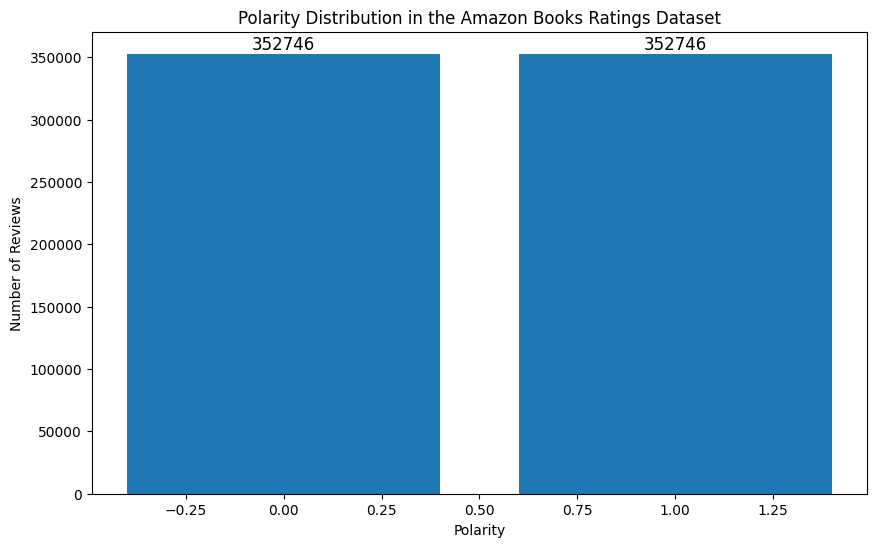

In [13]:
# plot the polarity distribution
DataUtils.plot_polarity_distribution_with_labels(amazon_balanced_df, 'Amazon Books Ratings')

In [14]:
# display the top 25 most frequent tokens
DataUtils.display_top_tokens(amazon_balanced_df, 'Review')

    Token   Count
0       !  151674
1     the   89732
2       ,   86095
3      of   80021
4       .   72914
5    book   70620
6       A   65915
7       a   64552
8     and   56237
9      to   45803
10    The   41887
11      I   41212
12    for   41086
13      ?   34016
14     is   33011
15    ...   31506
16     's   30342
17   this   29688
18     it   28007
19   read   25614
20    Not   24563
21  Great   24096
22     in   24006
23    n't   22904
24   Book   21991


In [15]:
# clean and preprocess data
amazon_preprocessed_df = DataUtils.preprocess_data(amazon_balanced_df)

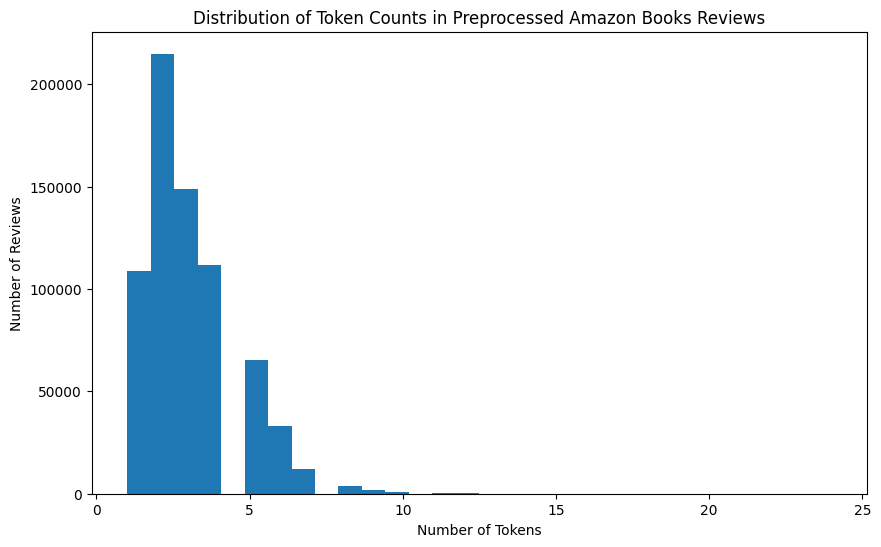

In [16]:
# plot the distribution of token counts
DataUtils.plot_token_distribution(amazon_preprocessed_df, 'Preprocessed Amazon Books Reviews')

In [17]:
# display the top 25 most frequent tokens
DataUtils.display_top_tokens(amazon_preprocessed_df, 'Review')

            Token   Count
0            book  103647
1           great   38449
2            read   36960
3            good   29465
4            best   19019
5             one   17226
6           story   15800
7         classic   12656
8            time   12126
9       excellent   12091
10           ever   11437
11           dont   11318
12         boring    9976
13           love    9475
14         review    9451
15          novel    8851
16  disappointing    8822
17            bad    8137
18           like    8088
19        reading    7163
20         better    7132
21        written    6931
22      wonderful    6921
23           life    6835
24          waste    6692


## 3.2 Data Preprocessing - Sentiment140

In [18]:
# unify numerical polarity value
sentiment140_df['Polarity'] = sentiment140_df['Polarity'].replace({0: 0, 4: 1})

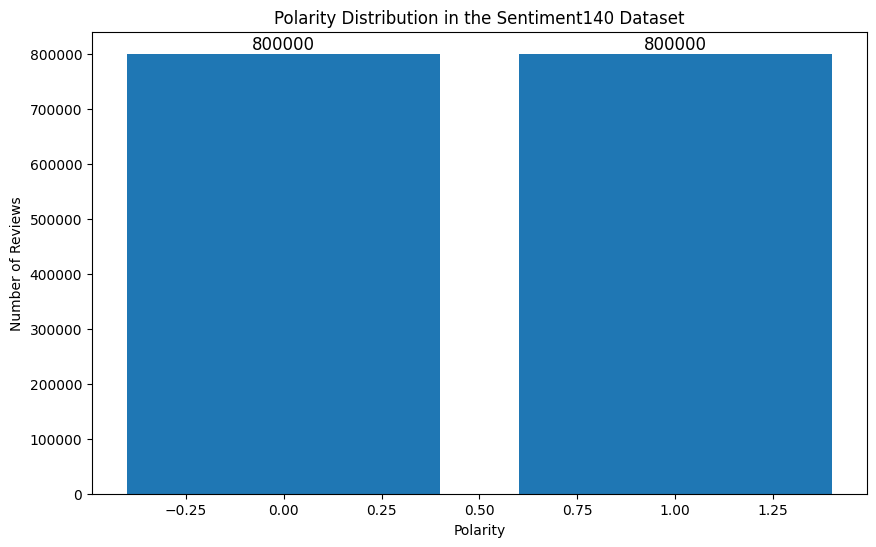

In [19]:
# plot the polarity distribution
DataUtils.plot_polarity_distribution_with_labels(sentiment140_df, 'Sentiment140')

In [20]:
# display the top 25 most frequent tokens
DataUtils.display_top_tokens(sentiment140_df, 'Review')  

   Token   Count
0      !  917950
1      .  804773
2      @  798682
3      I  652879
4     to  557549
5    the  490130
6      ,  484468
7      a  367729
8      i  299245
9     my  282842
10   and  281822
11   you  268826
12    it  260944
13     ?  247562
14    is  230283
15   ...  220073
16   for  211842
17    in  207194
18    of  180533
19    's  179216
20   n't  173581
21     ;  166822
22    on  160301
23    me  154979
24  that  147660


In [21]:
# clean and preprocess data
sentiment140_preprocessed_df = DataUtils.preprocess_data(sentiment140_df)

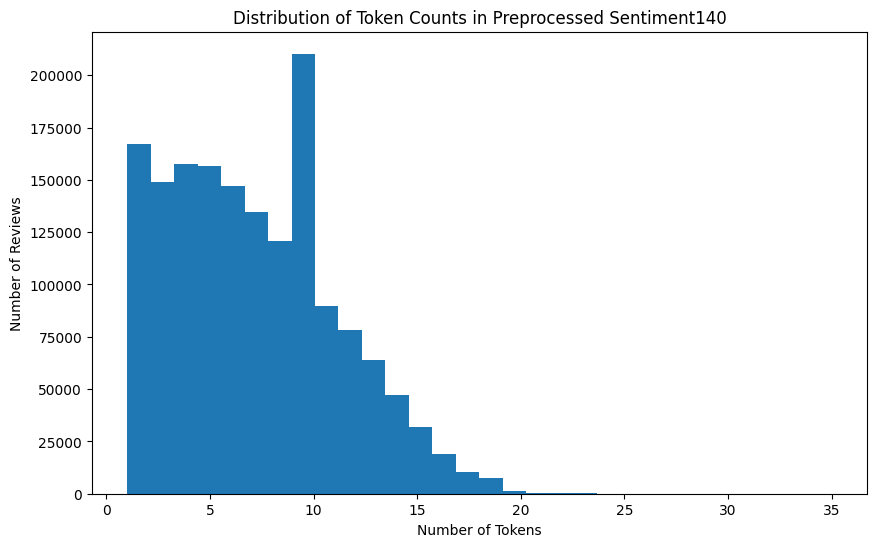

In [22]:
# plot the distribution of token counts
DataUtils.plot_token_distribution(sentiment140_preprocessed_df, 'Preprocessed Sentiment140')

In [23]:
# display the top 25 most frequent tokens
DataUtils.display_top_tokens(sentiment140_preprocessed_df, 'Review')

     Token   Count
0       im  178401
1      day  104035
2     good   89535
3      get   85934
4     like   79097
5       go   77449
6      got   69836
7        u   67387
8     dont   67306
9     love   66969
10    work   66498
11   today   66121
12   going   64104
13    time   63800
14    cant   62900
15    back   56120
16     one   55884
17     lol   55215
18    know   53227
19  really   49564
20    want   48317
21     see   46057
22    well   44566
23   night   43556
24   think   43502


## 3.3 Data Preprocessing - Yelp Reviews

In [24]:
# unify numerical polarity value
yelp_df['Polarity'] = yelp_df['Polarity'].replace({1: 0, 2: 1})

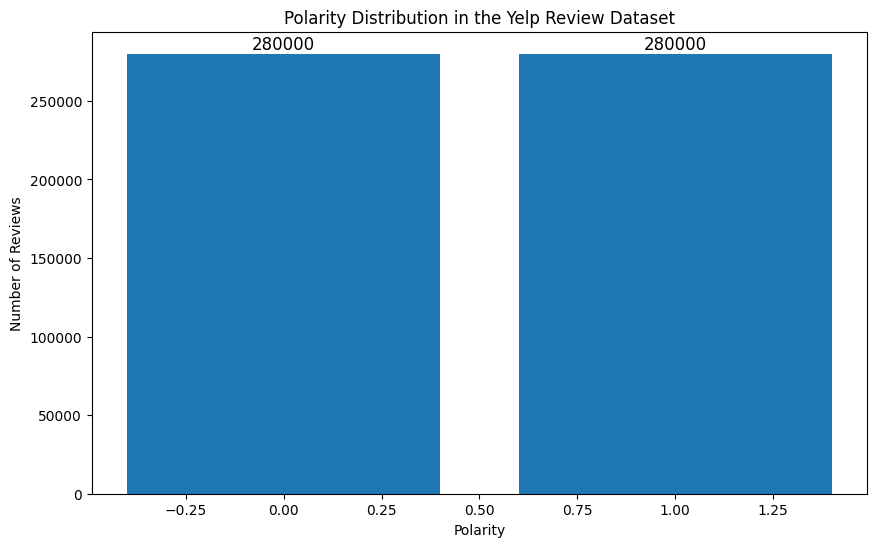

In [25]:
# plot the polarity distribution
DataUtils.plot_polarity_distribution_with_labels(yelp_df, 'Yelp Review')

In [26]:
# display the top 25 most frequent tokens
DataUtils.display_top_tokens(yelp_df, 'Review')  

   Token    Count
0      .  3977796
1    the  3169242
2      ,  2717635
3    and  2356227
4      I  2115246
5     to  1870691
6      a  1837871
7    was  1379177
8     of  1101404
9     it   928536
10    is   844433
11   for   837534
12    in   823774
13     !   790284
14  that   715968
15    my   566643
16  with   560569
17   you   549420
18   n't   539017
19   but   518953
20    on   512119
21   The   509584
22  this   475514
23  have   471896
24  they   458200


In [27]:
# clean and preprocess data
yelp_preprocessed_df = DataUtils.preprocess_data(yelp_df)

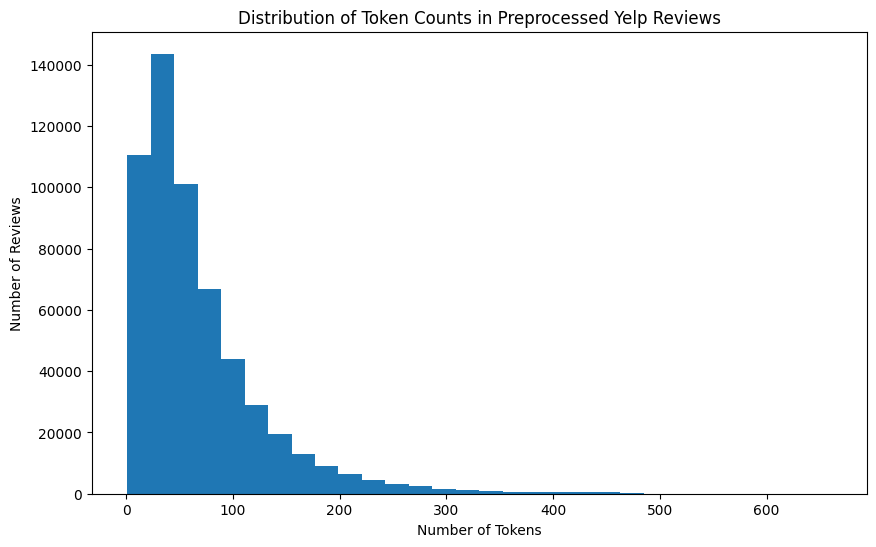

In [28]:
# plot the distribution of token counts
DataUtils.plot_token_distribution(yelp_preprocessed_df, 'Preprocessed Yelp Reviews')

In [29]:
# display the top 25 most frequent tokens
DataUtils.display_top_tokens(yelp_preprocessed_df, 'Review')

         Token   Count
0        place  350919
1         food  326244
2         good  292311
3         time  267502
4         like  261844
5          get  250554
6          one  243287
7      service  208301
8        would  206956
9        great  206022
10        back  191718
11          go  191241
12      really  167754
13           u  157722
14        dont  142085
15        even  140831
16         got  136687
17       didnt  120287
18  restaurant  119088
19        also  118454
20       order  115515
21          im  111199
22       never  108422
23     ordered  107389
24        nice  104650


# 4. Split and Save Data

In [30]:
# path to the folder where files will be saved (relative path)
output_dir = "../data/preprocessed/"

# split and save the Amazon dataset
DataUtils.split_and_save_dataset(output_dir, amazon_preprocessed_df, "amazon")

# split and save the Sentiment140 dataset
DataUtils.split_and_save_dataset(output_dir, sentiment140_preprocessed_df, "sentiment140")

# split and save the Yelp dataset
DataUtils.split_and_save_dataset(output_dir, yelp_preprocessed_df, "yelp")

print("Datasets have been saved in the folder:", os.path.abspath(output_dir))

Datasets have been saved in the folder: d:\projects\sentiment-analysis\data\preprocessed
